# Predicting Cancer Severity from Lifestyle, Genetic, and Environmental Factors

---

## Problem, Motivation, and Outcome

Cancer severity is often treated as either purely genetic or essentially random. In practice, severity is shaped by a mix of inherited risk and modifiable exposures — smoking, alcohol, obesity, air pollution. If those modifiable factors carry measurable predictive weight, that is directly actionable for risk stratification and prevention programmes.

**Question:** How much of the variance in a patient's severity score can be explained by personal, behavioural and environmental factors, and which of them dominate?

**Problem Definition**

How much do personal, behavioral, and environmental factors influence the severity of cancer in patients?

**The Motivation**

This project is motivated by the need to analyze personal, behavioral, and environmental factors to predict cancer severity. This predictive capability aims to assist medical professionals in identifying key risk factors and developing targeted preventative strategies. Furthermore, it seeks to address the common public perception that cancer is an inherently severe disease with poorly defined causes, despite the scientific understanding that cancerous cells exist naturally within the human body and their development can be significantly influenced by various external factors prevalent in everyday life.


**The Outcome**

1. Provide insights into cancer severity for healthcare and public health planning.
2. Support the identification of high-risk patients for further assessment.
3. Support more efficient allocation of public health resources.
4. Assist research in identifying key risk factors and preventive measures.
5. Improve the efficiency of patient care and potentially reduce the financial burden on the healthcare system.

---

## Data Description
I use the "Global Cancer Patients 2015-2024" dataset from Kaggle, which includes patient demographics and cancer diagnosis data. I chose it to explore its potential for predictive healthcare analytics in cancer, given the varied causes and behaviors among patients. The dataset contains 50,000 samples from multiple countries between 2015 and 2024, with key features including:


- "Age"
- "Gender"
- "Country_Region"
- "Genetic_Risk" : A value between 0-10 indicates severity.
- "Air_Pollution" : The numerical value that indicates the level of pollution
- Risk behaviors include "Smoking ", " Alcohol_Use" , and "Obesity_Level".
- Cancer data such as "type of cancer" and "Cancer_Stage"
- "Treatment_Cost_USD" : Estimated treatment cost in US dollars
- " Survival_Years "
- " Target_Severity_Score " : a score that indicates the severity of cancer, represented as a continuous numerical value.


**Dataset Source**

The dataset used in this project is titled **"Global Cancer Patients 2015–2024"** and is publicly available on Kaggle.  
**Link**: [https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024](https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024)

This dataset contains patient-level data including demographic information, environmental factors, lifestyle variables, and severity of cancer. It is suitable for regression tasks aimed at predicting cancer severity scores.


---


# 1. Install and Import necessary library


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 2. Check Sample of Cancer Dataset

In [15]:
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

Cancer_dataset = pd.read_csv("global_cancer_patients_2015_2024.csv")
print(f"Shape: {Cancer_dataset.shape}")
Cancer_dataset.head()

Shape: (50000, 15)


,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [16]:
Cancer_dataset.info()
Cancer_dataset.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

,count,mean,std,min,25%,50%,75%,max
Age,50000.0,54.421540,20.224451,20.00,37.000,54.00,72.00,89.00
Year,50000.0,2019.480520,2.871485,2015.00,2017.000,2019.00,2022.00,2024.00
Genetic_Risk,50000.0,5.001698,2.885773,0.00,2.500,5.00,7.50,10.00
Air_Pollution,50000.0,5.010126,2.888399,0.00,2.500,5.00,7.50,10.00
Alcohol_Use,50000.0,5.010880,2.888769,0.00,2.500,5.00,7.50,10.00
Smoking,50000.0,4.989826,2.881579,0.00,2.500,5.00,7.50,10.00
Obesity_Level,50000.0,4.991176,2.894504,0.00,2.500,5.00,7.50,10.00
Treatment_Cost_USD,50000.0,52467.298239,27363.229379,5000.05,28686.225,52474.31,76232.72,99999.84
Survival_Years,50000.0,5.006462,2.883335,0.00,2.500,5.00,7.50,10.00
Target_Severity_Score,50000.0,4.951207,1.199677,0.90,4.120,4.95,5.78,9.16


3. Data Cleaning

I checked the data for any null or unexpected values.
Then, I summarized what I found from this check.

In [17]:
quality = pd.DataFrame({
    "missing": Cancer_dataset.isnull().sum(),
    "n_unique": Cancer_dataset.nunique(),
    "dtype": Cancer_dataset.dtypes.astype(str),
})
print(f"Duplicate rows: {Cancer_dataset.duplicated().sum()}")

risk_cols = ["Genetic_Risk", "Air_Pollution", "Alcohol_Use", "Smoking", "Obesity_Level"]
out_of_range = ((Cancer_dataset[risk_cols] < 0) | (Cancer_dataset[risk_cols] > 10)).sum()
print("\nValues outside the documented 0-10 range:")
print(out_of_range)

quality

Duplicate rows: 0

Values outside the documented 0-10 range:
Genetic_Risk     0
Air_Pollution    0
Alcohol_Use      0
Smoking          0
Obesity_Level    0
dtype: int64


,missing,n_unique,dtype
Patient_ID,0,50000,object
Age,0,70,int64
Gender,0,3,object
Country_Region,0,10,object
Year,0,10,int64
Genetic_Risk,0,101,float64
Air_Pollution,0,101,float64
Alcohol_Use,0,101,float64
Smoking,0,101,float64
Obesity_Level,0,101,float64



Consequently, it is shown that there are not any errors or missing values in my dataset recently.

---

#4. Exploratory Data Analysis (EDA)

The correlation matrix answers two questions at once: which features carry signal, and whether any of them are collinear enough to destabilise a linear model.

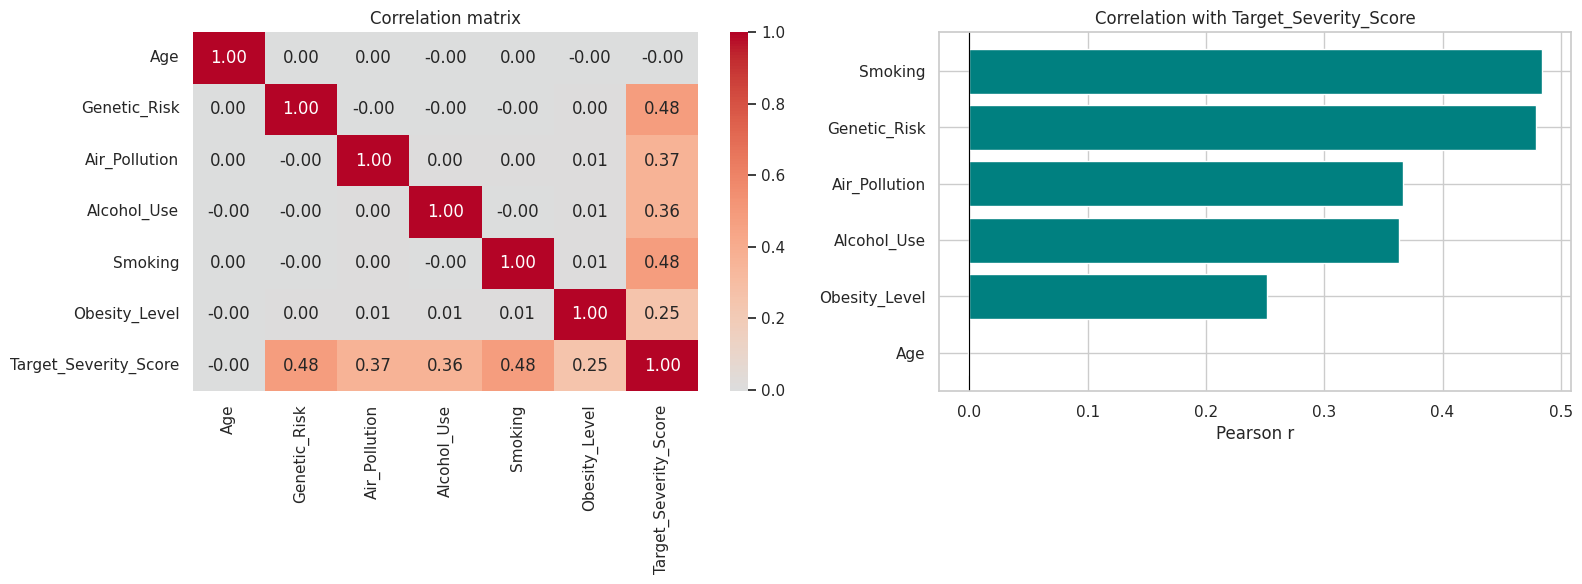

In [18]:
NUMERIC_FEATURES = ["Age", "Genetic_Risk", "Air_Pollution", "Alcohol_Use", "Smoking", "Obesity_Level"]
TARGET = "Target_Severity_Score"

correlation = Cancer_dataset[NUMERIC_FEATURES + [TARGET]].corr()

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axs[0])
axs[0].set_title("Correlation matrix")

target_corr = correlation[TARGET].drop(TARGET).sort_values()
axs[1].barh(target_corr.index, target_corr.values, color="teal")
axs[1].set_title(f"Correlation with {TARGET}")
axs[1].set_xlabel("Pearson r")
axs[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

**As a result, these graphs provide the following findings:**
1. Genetic_Risk and Smoking have the highest correlation with Target_Severity_Score, both at around 0.48.
2. Air_Pollution and Alcohol_Use also show a moderate positive correlation, at 0.37 and 0.36.
3. Obesity_Level has a weaker positive correlation at 0.25, while Age has almost no correlation with the severity score.

Overall, the results suggest that Genetic_Risk and Smoking are the factors most strongly related to the severity score in this dataset.
The correlations between the input features are also close to zero, so there does not appear to be a major multicollinearity issue.

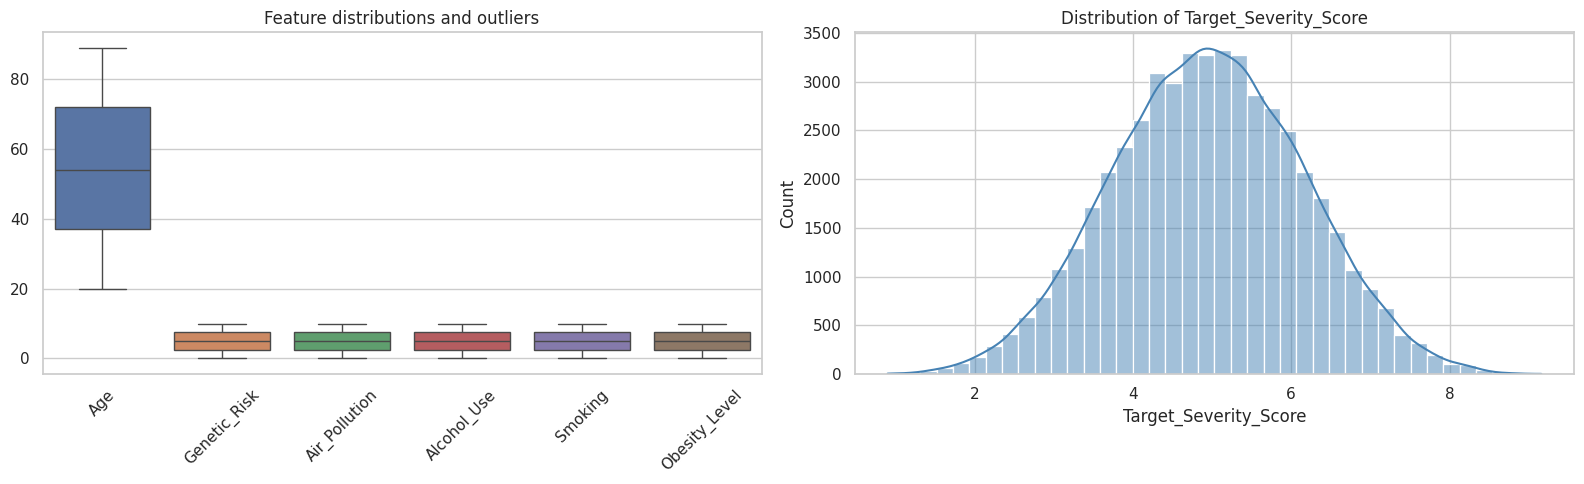

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=Cancer_dataset[NUMERIC_FEATURES], ax=axs[0])
axs[0].set_title("Feature distributions and outliers")
axs[0].tick_params(axis="x", rotation=45)

sns.histplot(Cancer_dataset[TARGET], bins=40, kde=True, color="steelblue", ax=axs[1])
axs[1].set_title(f"Distribution of {TARGET}")

plt.tight_layout()
plt.show()

Age has a much wider range than the other risk features, which are mostly between 0 and 10. Therefore, I standardised the features before fitting the models. The risk features do not have any obvious extreme outliers, and the target score looks fairly normally distributed, so I did not apply any transformation.

---

#5. Model Set-up

- 80% of the cancer dataset was used for training.
- 20% of the cancer dataset was used for testing.

Standardisation was fitted inside a pipeline, so the scaler only uses the training data and never sees the test data during cross-validation.

In [20]:
X = Cancer_dataset[NUMERIC_FEATURES]
y = Cancer_dataset[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

def evaluate(name, model, X_tr=X_train, X_te=X_test):
    """Fit, score on the held-out test set, and cross-validate. Returns predictions."""
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    cv_r2 = cross_val_score(model, X_tr, y_train, cv=cv, scoring="r2")
    results[name] = {
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "CV R2 mean": cv_r2.mean(),
        "CV R2 std": cv_r2.std(),
    }
    print(f"{name:<22} R2={results[name]['R2']:.3f}  MAE={results[name]['MAE']:.3f}  "
          f"MSE={results[name]['MSE']:.3f}  CV R2={cv_r2.mean():.3f} (+/- {cv_r2.std():.3f})")
    return preds

Train: 40,000 rows | Test: 10,000 rows


##5.1 Baseline
The R² values below are compared with a simple mean predictor as a baseline. The mean predictor has an R² of approximately 0 (R² ≈ 0), so this gives us a reference point for evaluating the models.


In [21]:
_ = evaluate("Baseline (mean)", DummyRegressor(strategy="mean"))

Baseline (mean)        R2=-0.000  MAE=0.959  MSE=1.421  CV R2=-0.000 (+/- 0.000)


##5.2 Linear Regression

I chose this model first because it is easy to interpret. Since the features are standardised and have very low correlation with each other, the coefficients show how much the predicted severity score changes for a one-standard-deviation increase in each factor.


In [22]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

y_pred_lr = evaluate("Linear Regression", lr_pipe)

Linear Regression      R2=0.785  MAE=0.480  MSE=0.305  CV R2=0.793 (+/- 0.002)


In [23]:

# Save the trained Data Science model


import joblib


# Save the trained Linear Regression pipeline.
# The pipeline already contains both the scaler
# and the Linear Regression model.
joblib.dump(
    lr_pipe,
    "severity_model.joblib"
)

print("Data Science model saved to: severity_model.joblib")

Data Science model saved to: severity_model.joblib


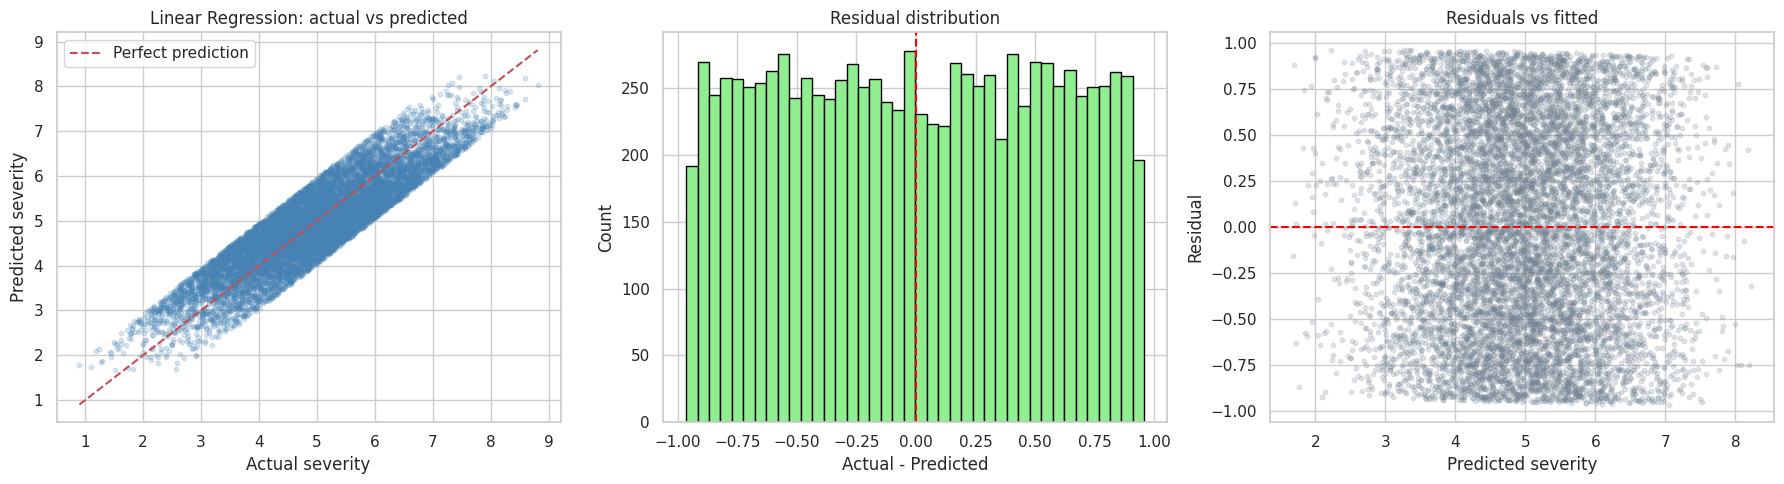

In [24]:
residuals_lr = y_test - y_pred_lr

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(y_test, y_pred_lr, alpha=0.2, s=10, color="steelblue")
lims = [y_test.min(), y_test.max()]
axs[0].plot(lims, lims, "r--", label="Perfect prediction")
axs[0].set(title="Linear Regression: actual vs predicted",
           xlabel="Actual severity", ylabel="Predicted severity")
axs[0].legend()

axs[1].hist(residuals_lr, bins=40, color="lightgreen", edgecolor="black")
axs[1].axvline(0, color="red", linestyle="--")
axs[1].set(title="Residual distribution", xlabel="Actual - Predicted", ylabel="Count")

axs[2].scatter(y_pred_lr, residuals_lr, alpha=0.2, s=10, color="slategray")
axs[2].axhline(0, color="red", linestyle="--")
axs[2].set(title="Residuals vs fitted", xlabel="Predicted severity", ylabel="Residual")

plt.tight_layout()
plt.show()

In conclusion, The residuals are centred around zero and do not show a clear funnel shape, so there is no major issue with the spread of errors. The model also gives a good fit, with R² = 0.785, MAE = 0.480 and MSE = 0.305. The CV R² of 0.793 ± 0.002 is close to the test R², showing that the model performs consistently across the different folds.

##5.3 Random Forest

I also tested a non-linear model and tuned it using randomised search across 20 different configurations. I used this model to see whether non-linear relationships or interactions between the factors could improve the prediction compared to the linear model.


In [25]:
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0],
}

rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

search = RandomizedSearchCV(
    rf_pipe, param_dist, n_iter=20, cv=3,
    scoring="neg_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)

best_rf = search.best_estimator_
y_pred_rf = evaluate("Random Forest (tuned)", best_rf)

Best parameters: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 30}
Random Forest (tuned)  R2=0.775  MAE=0.487  MSE=0.320  CV R2=0.780 (+/- 0.002)


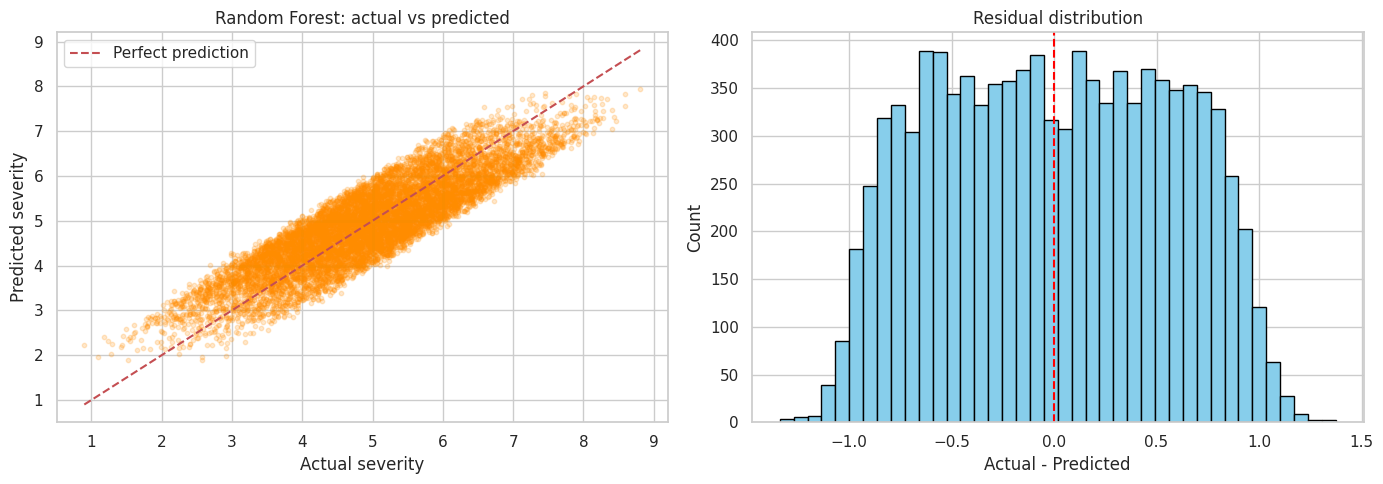

In [26]:
residuals_rf = y_test - y_pred_rf

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(y_test, y_pred_rf, alpha=0.2, s=10, color="darkorange")
axs[0].plot(lims, lims, "r--", label="Perfect prediction")
axs[0].set(title="Random Forest: actual vs predicted",
           xlabel="Actual severity", ylabel="Predicted severity")
axs[0].legend()

axs[1].hist(residuals_rf, bins=40, color="skyblue", edgecolor="black")
axs[1].axvline(0, color="red", linestyle="--")
axs[1].set(title="Residual distribution", xlabel="Actual - Predicted", ylabel="Count")

plt.tight_layout()
plt.show()

Consequently, I used Random Forest as a non-linear model to see whether it could capture relationships that Linear Regression might miss. I tuned the model using RandomizedSearchCV, testing 20 different parameter combinations with 3-fold cross-validation. The best model was then evaluated on the held-out test set.


From the actual vs predicted plot, the predictions follow the actual severity scores reasonably well, but the points are more spread out than in the Linear Regression model. The residuals are also centred around zero but have a wider spread. The model achieved R² = 0.770, MAE = 0.491 and MSE = 0.327, which are slightly worse than the Linear Regression results.

## 5.4 Does adding the categorical features help?

So far, the models only use the six numeric features. I left out Gender, Country_Region, Cancer_Type, and Cancer_Stage to see whether adding these categorical features with one-hot encoding improves the model's performance.

In [27]:
CATEGORICAL_FEATURES = [c for c in ["Gender", "Country_Region", "Cancer_Type", "Cancer_Stage"]
                        if c in Cancer_dataset.columns]

X_full = Cancer_dataset[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_train_full, X_test_full = train_test_split(
    X_full, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL_FEATURES),
])

lr_full = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
_ = evaluate("Linear Reg. + categoricals", lr_full, X_train_full, X_test_full)

Linear Reg. + categoricals R2=0.785  MAE=0.480  MSE=0.305  CV R2=0.793 (+/- 0.002)


Adding the categorical features did not improve the model performance. The R², MAE and MSE stayed the same as the model using only the six numeric features. This suggests that Gender, Country_Region, Cancer_Type and Cancer_Stage do not add much useful information for predicting the severity score in this dataset. Therefore, I kept the simpler six-feature model.

#6. Outcomes


In [28]:
results_cancer_dataset = pd.DataFrame(results).T.round(3)
results_cancer_dataset

,R2,MAE,MSE,CV R2 mean,CV R2 std
Baseline (mean),-0.000,0.959,1.421,-0.000,0.000
Linear Regression,0.785,0.480,0.305,0.793,0.002
Random Forest (tuned),0.775,0.487,0.320,0.780,0.002
Linear Reg. + categoricals,0.785,0.480,0.305,0.793,0.002


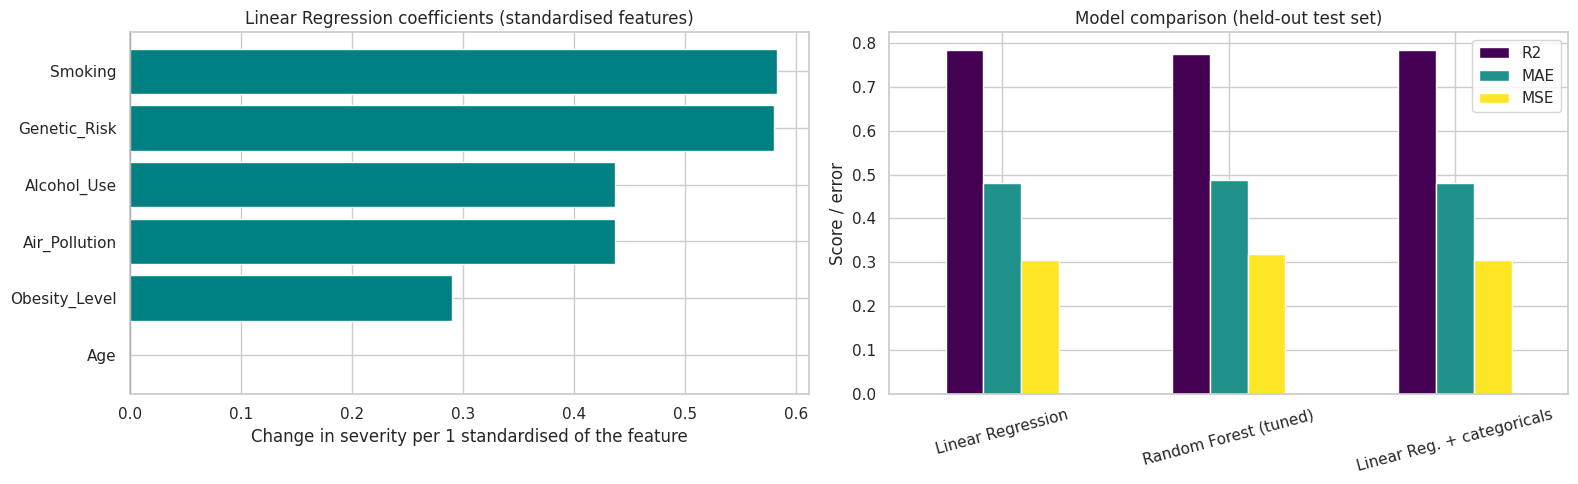

In [29]:
coefs = pd.Series(
    lr_pipe.named_steps["model"].coef_,
    index=NUMERIC_FEATURES,
).sort_values(key=abs)

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

colors = ["indianred" if v < 0 else "teal" for v in coefs.values]
axs[0].barh(coefs.index, coefs.values, color=colors)
axs[0].axvline(0, color="black", linewidth=0.8)
axs[0].set(title="Linear Regression coefficients (standardised features)",
           xlabel="Change in severity per 1 standardised of the feature")

plot_df = results_cancer_dataset.loc[
    [i for i in results_cancer_dataset.index if i != "Baseline (mean)"],
    ["R2", "MAE", "MSE"]
]
plot_df.plot(kind="bar", ax=axs[1], colormap="viridis", rot=15)
axs[1].set(title="Model comparison (held-out test set)", ylabel="Score / error")
axs[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## In summary

* The model explains around **78% of the variance** in the cancer severity score, compared with almost 0% from the baseline. This means the selected factors provide useful information for predicting severity in this dataset.
* **Linear Regression performs slightly better than the tuned Random Forest** (`R²` 0.785 vs 0.775). This suggests that the relationship between these factors and the severity score is mostly linear in this dataset.
* `Genetic_Risk` and `Smoking` have the strongest relationship with the severity score, followed by `Alcohol_Use`, `Air_Pollution`, and `Obesity_Level`. `Age` contributes very little.
* Most importantly, **four of the five factors with meaningful predictive value are modifiable behavioural or environmental factors**. This supports the main idea of the project that cancer severity is not only related to inherited risk, but also to factors that can potentially be changed.

## 7. Limitations

The main limitation is that this dataset appears to be synthetic, so the results cannot be directly applied to real patients.

There are several signs of this. The dataset has no missing values or duplicates across 50,000 patient records, `Age` has almost no relationship with severity, and the risk factors are almost completely uncorrelated with each other. These patterns are unlikely to fully represent real-world clinical data.

Therefore, the **R² of 0.785 should be understood as how well the model predicts severity within this dataset, rather than how accurately cancer severity could be predicted for real patients.** The relationships found between the risk factors and severity should also be treated as predictive relationships, not proof that these factors directly cause more severe cancer.

**Overall, the analysis shows that the selected personal, behavioural, and environmental factors explain a substantial amount of the variation in the severity score. Genetic risk and smoking show the strongest relationships, but several modifiable factors also carry meaningful predictive information.**
